In [ ]:
import torch
import numpy as np
from vllm import LLM, SamplingParams
from tqdm import tqdm
import argparse
import os
import json
import sys
sys.path.append('/groups/nchawla/phuc/Medidcal-UnderThink/evaluation')
from data import *
from extract_format import extract_answer, huatuo_match_choice
from collect_eval_data import load_huatuo_eval
from eval_budget_forcing import compute_score, final_answer_generate, budget_forcing_generate
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [ ]:
eval_data = load_huatuo_eval()
eval_data = {k: eval_data[k] for k in ['GPQA_Medical_test']}

In [ ]:
model_path = 'checkpoints/medgemma-4b-pt-m1/global_step_6400/huggingface'
n_gpus = 1
llm = LLM(model_path, enforce_eager=False, max_num_seqs=2048, max_model_len=32768, tensor_parallel_size=n_gpus, gpu_memory_utilization=0.8, max_num_batched_tokens=16384)
tokenizer = llm.get_tokenizer()

In [36]:
MAX_TOKENS_THINKING = 2560

for k in eval_data.keys():
    chat_prompts = [ele['question'] for ele in eval_data[k]]
    answer_idxs = [ele['answer_idx'] for ele in eval_data[k]]
    answer_strs= [ele['answer'] for ele in eval_data[k]]
    option_strs = [ele['options'] for ele in eval_data[k]]
    
    instruction_following = 'Please reason step by step, and put your final answer within \\boxed{}.'
    progress_bar = tqdm(range(len(chat_prompts)))
    total_scores = 0.0
    total_count = 0
    if tokenizer.chat_template is not None:
        prompts = [tokenizer.apply_chat_template([{"role": "user", "content": chat_prompts[i] + "\n" + instruction_following}], tokenize=False, add_generation_prompt=True) + "\n<think>" for i in range(len(chat_prompts))]
    else:
        prompts = [chat_prompts[i] + "\n" + instruction_following + "\n<think>" for i in range(len(chat_prompts))]
    
    ignore_str = "\nWait"
    stop_token_ids = tokenizer("</think>")["input_ids"]
    sampling_params = SamplingParams(max_tokens=MAX_TOKENS_THINKING, temperature=0.0, min_tokens=0, stop_token_ids=stop_token_ids, skip_special_tokens=False)
    # outputs = llm.generate(prompts + "\n\n</think>", sampling_params=sampling_params, use_tqdm=True)
    answer_txt = "\nTime is up. Given the time I’ve spent and the approaches I’ve tried, I should stop thinking and formulate a final answer based on what I already have.\n</think>"
    outputs = llm.generate([prompt + answer_txt for prompt in prompts], sampling_params=sampling_params, use_tqdm=True)
    prompts = [prompt + output.outputs[0].text for prompt, output in zip(prompts, outputs)]
    budget_tokens = [MAX_TOKENS_THINKING - len(output.outputs[0].token_ids) for output in outputs]

Processed prompts: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 390/390 [02:31<00:00,  2.57it/s, est. speed input: 509.91 toks/s, output: 3967.39 toks/s]


In [39]:
all_scores = [float(compute_score(prompts[i], answer_strs[i], answer_idxs[i], option_strs[i])) for i in range(len(prompts))]
print(f"Accuracy for {k}: {sum(all_scores) / len(all_scores)}")
print(prompts[0])

Accuracy for GPQA_Medical_test: 0.2358974358974359
A large gene has dozens of exons, of which the central ones code for folded triple helical repeats that connect the cytoskeleton with sarcolemma and extracellular space. Each exon usually codes for one folded triple alpha helix. The most common mutations of the gene are central exon deletions that create out-of-frame peptides and progressive degenerative organ waste. A solution is to deliver a Morpholino that recognizes the 5' end of the out-of-frame exon in pre-mRNA. The molecule prevents binding of the spliceosome and creates exon skipping and in-frame joining. Several missing exons are well tolerated by an organism. Which structure below is not involved in the proposed therapy?
Please reason step by step, and put your final answer within \boxed{}.
<think>
The question involves a gene therapy approach for a disease caused by a large gene with multiple exons, specifically targeting a central exon that codes for folded triple helical r

In [ ]:
all_outputs = []
NUM_TRIALS = 10
def budget_forcing_generate(prompt, max_budget_tokens, llm, n_trials: int = 1):
    stop_token_ids = tokenizer("</think>")["input_ids"]
    ignore_str = "\nWait"
    max_tokens_thinking_tmp = max_budget_tokens
    if max_tokens_thinking_tmp > 0:
        for i in range(n_trials):
            sampling_params = SamplingParams(max_tokens=max_tokens_thinking_tmp, temperature=0.0, min_tokens=1, stop_token_ids=stop_token_ids, skip_special_tokens=False, repetition_penalty=1.2)
            o = llm.generate(prompt, sampling_params=sampling_params, use_tqdm=False)
            max_tokens_thinking_tmp -= min([len(o[i].outputs[0].token_ids) for i in range(len(o))])
            if max_tokens_thinking_tmp > 0:
                prompt = prompt + o[0].outputs[0].text + ignore_str
            else:
                break
        prompt += o[0].outputs[0].text
    return prompt

for i in range(len(prompts)):
    prompt = prompts[i]
    if budget_tokens[i] > 0:
        output = budget_forcing_generate(prompt + ignore_str, budget_tokens[i], llm, NUM_TRIALS)
    else:
        output = prompt
    all_outputs.append(output)

In [ ]:
print(prompts[-1])

In [ ]:
answer_txt = "\nTime is up. Given the time I’ve spent and the approaches I’ve tried, I should stop thinking and formulate a final answer based on what I already have.\n</think>"
all_outputs = [output + answer_txt for output in all_outputs]
all_finals = final_answer_generate(all_outputs, llm)

In [ ]:
print(all_outputs[0][len(prompts[0])-300:])

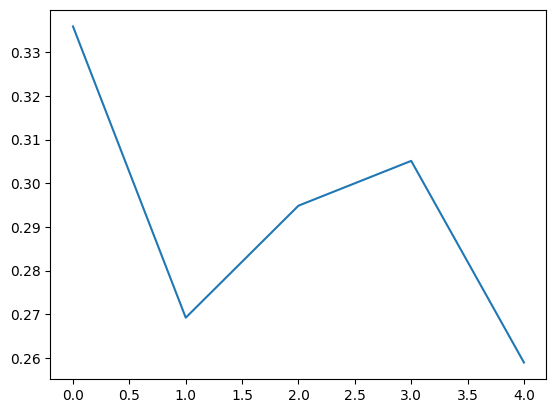

In [29]:
import json
import pandas as pd

all_results = []
with open("eval/results_budget_forcing.json", "r") as f:
    for line in f:
        all_results.append(json.loads(line))
df = pd.DataFrame(all_results)
med_df = df[df['model_path'].str.contains('medgemma')]
gem_df = df[df['model_path'].str.contains('gemma-3')]

accs = med_df['GPQA_Medical_test'].tolist()
gem_accs = gem_df['GPQA_Medical_test'].tolist()

import matplotlib.pyplot as plt
plt.plot([0, 1, 2, 3, 4], gem_accs)
# plt.legend(['medgemma', 'gemma-3'])
# plt.show()

In [ ]:
answer_idxs[0]